In [1]:
from google import genai

from config import GEMINI_API_KEY

if not GEMINI_API_KEY:
    raise RuntimeError("Set GEMINI_API_KEY (or GOOGLE_API_KEY) in .env")

client = genai.Client(api_key=GEMINI_API_KEY)

result = client.models.embed_content(
        model="gemini-embedding-001",
        contents= [
            "What is the meaning of life?",
            "What is the purpose of existence?",
            "How do I bake a cake?"
        ]
)

for embedding in result.embeddings:
    print(embedding)

    


values=[-0.022374554, -0.004560777, 0.013309286, -0.0545072, -0.02090443, 0.012355714, 0.015772128, 0.0054723006, 0.031729158, 0.0058553913, 0.027073925, -0.0045324513, -0.01544016, 0.031618375, 0.121548004, 0.01925409, 0.0008599909, 0.0061733276, -0.009662611, -0.015545654, 0.017062597, -0.008637558, -0.017125048, 0.0077396077, -0.0153139075, 0.011430326, 0.020329107, -0.00451, 0.024133444, 0.0070407446, 0.020197608, 0.0015623937, -0.008911156, 0.028138846, -0.017435355, -0.012656962, 0.009481721, -0.016410641, -0.015019126, 0.0144167375, -0.023614116, -0.010397569, -0.0024164703, -0.019404082, 0.019276941, -0.011112846, 0.014422737, -0.042639293, -0.014391114, 0.008184219, -0.012202394, 0.012318022, -0.010061107, -0.15826157, 0.015428178, 0.01053043, -0.0069031497, -0.010121202, -0.025695775, -0.028000489, -0.0070861652, -0.014084083, -0.008487853, -0.022122845, 0.0084621115, -0.008990799, -0.020783192, 0.010838266, 0.0013916494, 0.011982546, -0.015935048, 0.015096186, -0.0058905873,

# Embedding Analysis & Visualization

Load the per-PDF Gemini embeddings from `embeddings/` and explore them with:

- Summary stats (dimension, norms, value distribution)
- Pairwise cosine similarity + Euclidean distance heatmaps
- Linear projection: **PCA** (2D and 3D)
- Non-linear projections: **t-SNE** and **UMAP**
- **Hierarchical clustering** dendrogram
- Per-document embedding signature heatmap

In [6]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

EMB_DIR = Path("embeddings")


def short_label(stem: str) -> str:
    """Turn a long file stem into a compact section label."""
    tail = stem.split("__", 1)[-1]
    tail = re.sub(r"_p\d+-p\d+", "", tail)
    return tail.replace("_", " ").strip()


records = []
for path in sorted(EMB_DIR.glob("*.json")):
    data = json.loads(path.read_text())
    records.append(
        {
            "file": data["file"],
            "label": short_label(path.stem),
            "embedding": np.asarray(data["embedding"], dtype=np.float32),
        }
    )

df = pd.DataFrame(records)
X = np.vstack(df["embedding"].to_numpy())
labels = df["label"].tolist()

print(f"Loaded {len(df)} embeddings, dim = {X.shape[1]}")
df[["file", "label"]]

Loaded 8 embeddings, dim = 3072


,file,label
0,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,01 Cover-Page
1,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,02 Transmittal-Letter
2,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,03 Organizational-Chart
3,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,04 Project-Experience
4,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,05 Project-Approach-QA-QC
5,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,06 Key-Personnel
6,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,07 Scope-of-Work
7,Apex-Civic-Plaza-&-Municipal-Office-Tower-Prop...,08 Conclusion


## 1. Summary statistics

Vector norms tell us whether embeddings are already L2-normalised and how much each
document's raw magnitude differs.

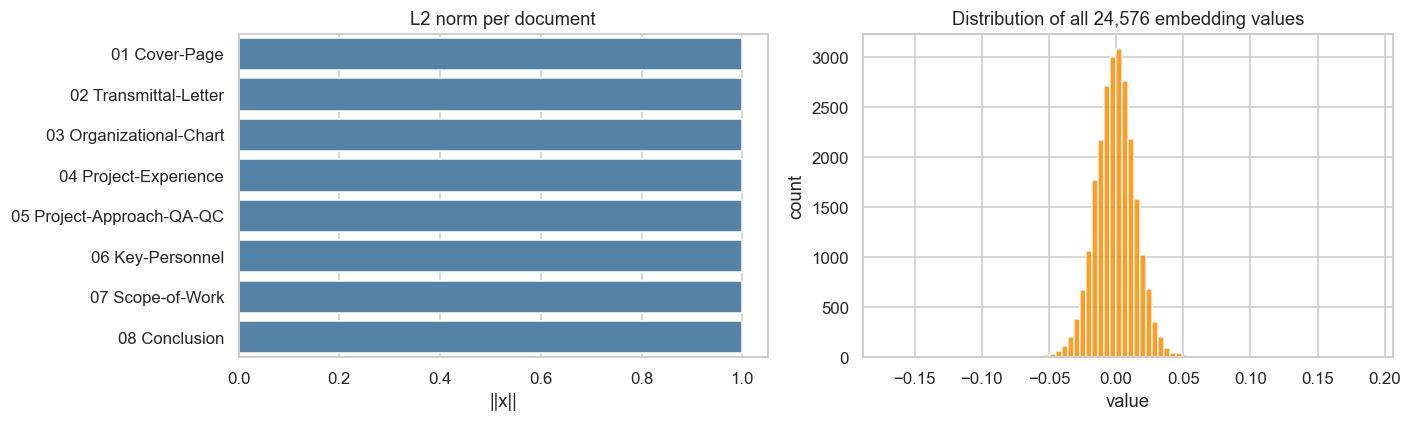

,label,norm,mean,std,min,max
0,01 Cover-Page,1.0,-0.0002,0.018,-0.1495,0.1692
1,02 Transmittal-Letter,1.0,-0.0001,0.018,-0.1320,0.1616
2,03 Organizational-Chart,1.0,-0.0003,0.018,-0.1602,0.1751
3,04 Project-Experience,1.0,-0.0005,0.018,-0.1701,0.1829
4,05 Project-Approach-QA-QC,1.0,-0.0002,0.018,-0.1196,0.1288
5,06 Key-Personnel,1.0,-0.0002,0.018,-0.1667,0.1879
6,07 Scope-of-Work,1.0,-0.0005,0.018,-0.1308,0.1406
7,08 Conclusion,1.0,-0.0002,0.018,-0.1441,0.1593


In [7]:
import numpy as np
norms = np.linalg.norm(X, axis=1)
stats = pd.DataFrame(
    {
        "label": labels,
        "norm": norms,
        "mean": X.mean(axis=1),
        "std": X.std(axis=1),
        "min": X.min(axis=1),
        "max": X.max(axis=1),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x="norm", y="label", data=stats, ax=axes[0], color="steelblue")
axes[0].set_title("L2 norm per document")
axes[0].set_xlabel("||x||")
axes[0].set_ylabel("")

axes[1].hist(X.flatten(), bins=80, color="darkorange", alpha=0.85)
axes[1].set_title(f"Distribution of all {X.size:,} embedding values")
axes[1].set_xlabel("value")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

stats.round(4)

## 2. Pairwise similarity & distance

Cosine similarity highlights semantic closeness; Euclidean distance complements it with
magnitude-sensitive separation.

/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


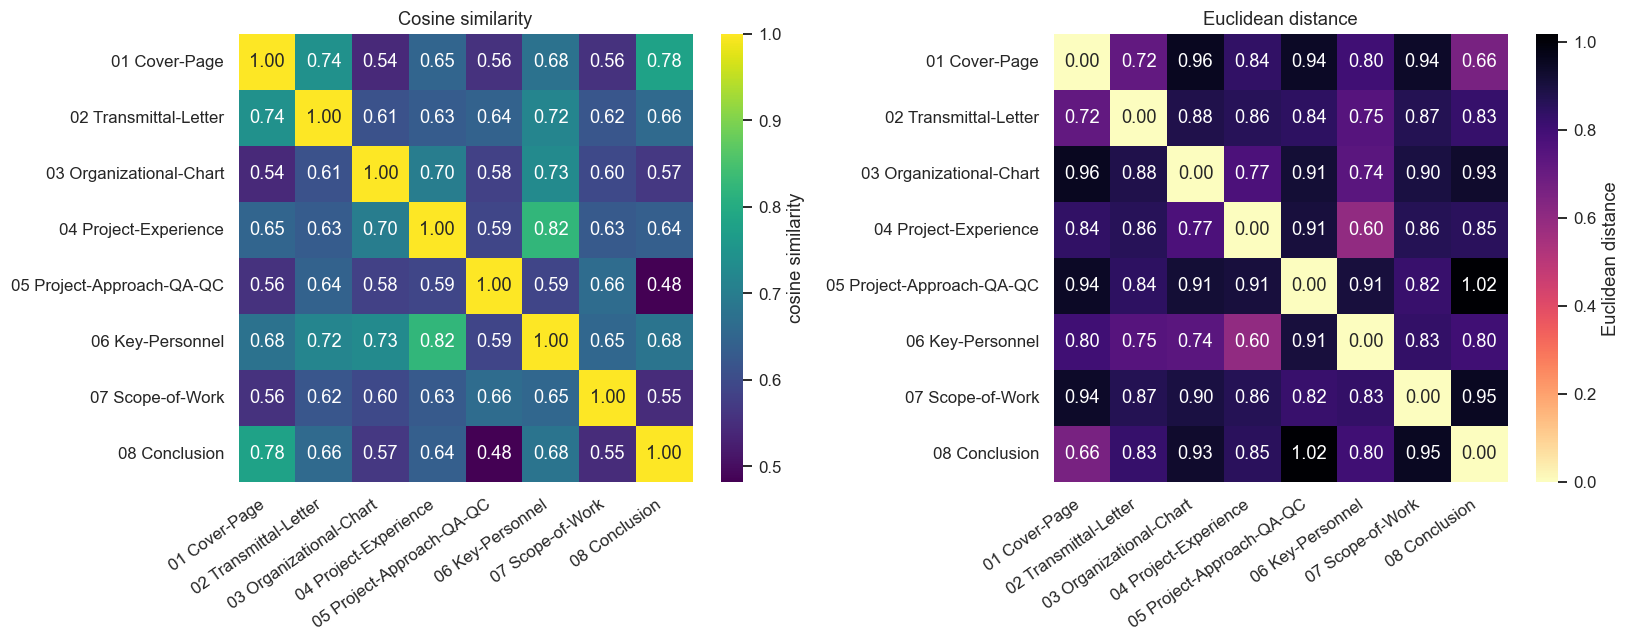

In [8]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

cos_sim = cosine_similarity(X)
euc_dist = euclidean_distances(X)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(
    cos_sim,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    cbar_kws={"label": "cosine similarity"},
)
axes[0].set_title("Cosine similarity")

sns.heatmap(
    euc_dist,
    annot=True,
    fmt=".2f",
    cmap="magma_r",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1],
    cbar_kws={"label": "Euclidean distance"},
)
axes[1].set_title("Euclidean distance")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 3. PCA — linear projection (2D & 3D)

PCA gives an interpretable low-dim view and tells us how much variance the top
components capture.

/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-

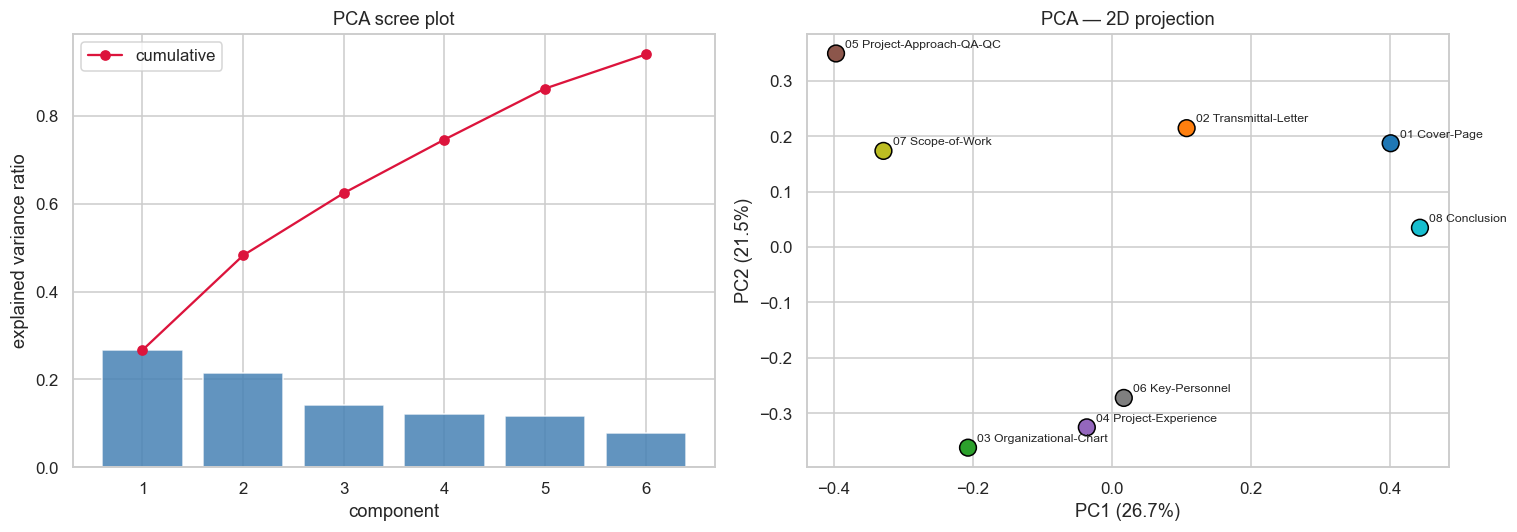

In [9]:
from sklearn.decomposition import PCA

n_comp = min(X.shape[0], 6)
pca_full = PCA(n_components=n_comp).fit(X)
explained = pca_full.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_comp + 1), explained, color="steelblue", alpha=0.85)
axes[0].plot(range(1, n_comp + 1), np.cumsum(explained), "o-", color="crimson", label="cumulative")
axes[0].set_xlabel("component")
axes[0].set_ylabel("explained variance ratio")
axes[0].set_title("PCA scree plot")
axes[0].legend()

pca2 = PCA(n_components=2).fit_transform(X)
axes[1].scatter(pca2[:, 0], pca2[:, 1], s=120, c=range(len(labels)), cmap="tab10", edgecolors="black")
for i, lab in enumerate(labels):
    axes[1].annotate(lab, (pca2[i, 0], pca2[i, 1]), fontsize=8, xytext=(6, 4), textcoords="offset points")
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}%)")
axes[1].set_title("PCA — 2D projection")
plt.tight_layout()
plt.show()

In [6]:
import plotly.express as px

pca3 = PCA(n_components=3).fit_transform(X)
pca3_df = pd.DataFrame(pca3, columns=["PC1", "PC2", "PC3"])
pca3_df["label"] = labels

fig = px.scatter_3d(
    pca3_df,
    x="PC1",
    y="PC2",
    z="PC3",
    text="label",
    color="label",
    title="PCA — interactive 3D projection",
)
fig.update_traces(marker=dict(size=7, line=dict(width=1, color="black")))
fig.update_layout(height=600, showlegend=False)
fig.show()

/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-

## 4. Non-linear projections — t-SNE & UMAP

With only a handful of points, both methods are used mostly for visual sanity-checks;
`perplexity` / `n_neighbors` are capped below the sample count.

/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/thefreakingmind/JoistWork/search_v2/.venv/lib/python3.10/site-

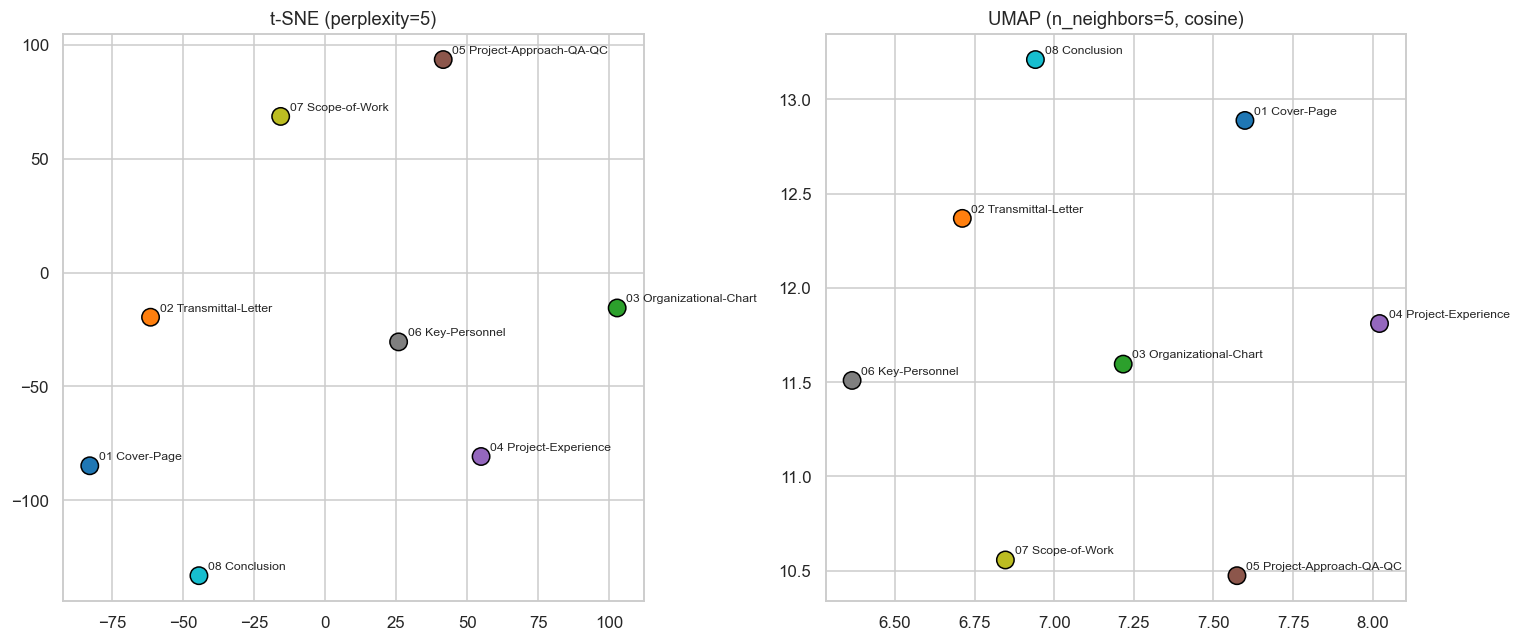

In [7]:
import warnings
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=UserWarning)

n = X.shape[0]
perplexity = max(2, min(5, n - 1))
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X)

try:
    import umap

    n_neighbors = max(2, min(5, n - 1))
    umap_proj = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=0.1,
        metric="cosine",
        random_state=42,
    ).fit_transform(X)
    have_umap = True
except Exception as e:
    print(f"UMAP unavailable: {e}")
    have_umap = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(tsne[:, 0], tsne[:, 1], s=130, c=range(n), cmap="tab10", edgecolors="black")
for i, lab in enumerate(labels):
    axes[0].annotate(lab, (tsne[i, 0], tsne[i, 1]), fontsize=8, xytext=(6, 4), textcoords="offset points")
axes[0].set_title(f"t-SNE (perplexity={perplexity})")

if have_umap:
    axes[1].scatter(
        umap_proj[:, 0], umap_proj[:, 1], s=130, c=range(n), cmap="tab10", edgecolors="black"
    )
    for i, lab in enumerate(labels):
        axes[1].annotate(
            lab, (umap_proj[i, 0], umap_proj[i, 1]), fontsize=8, xytext=(6, 4), textcoords="offset points"
        )
    axes[1].set_title(f"UMAP (n_neighbors={n_neighbors}, cosine)")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Hierarchical clustering

Using cosine distance and average linkage to see which sections cluster together.

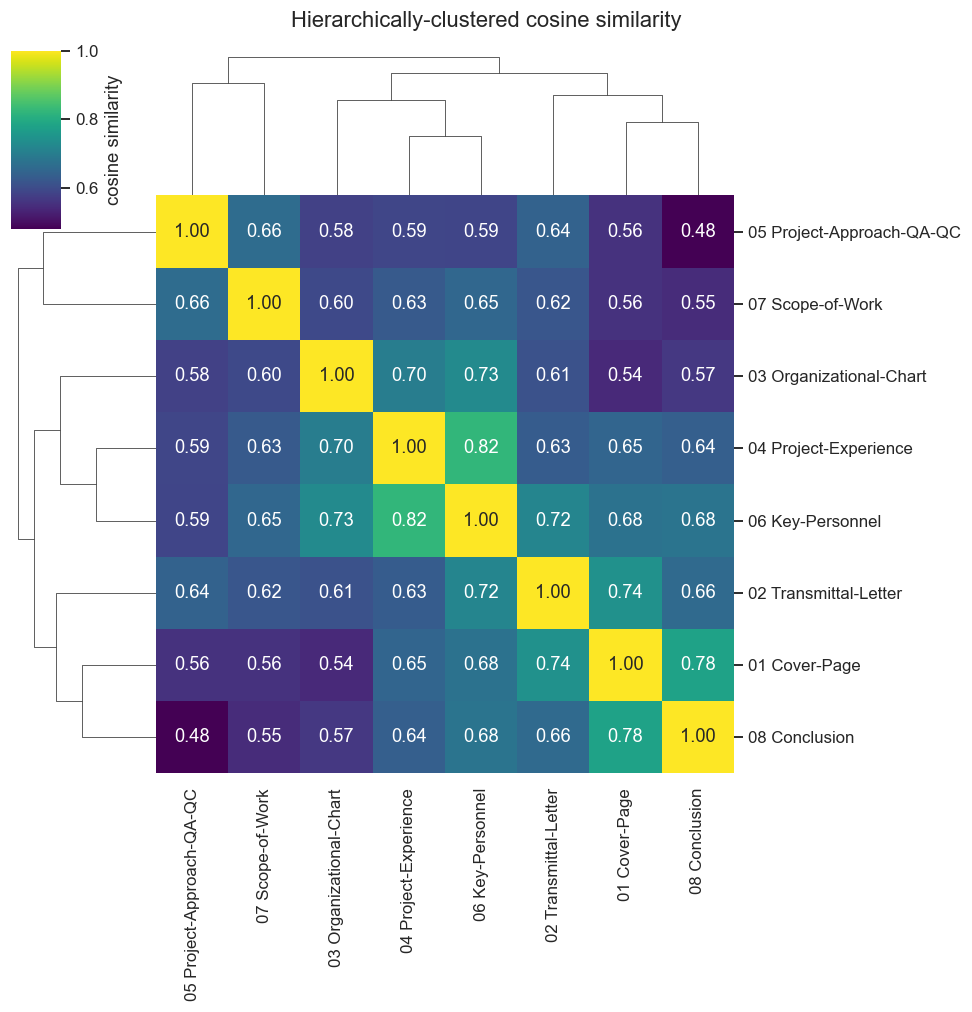

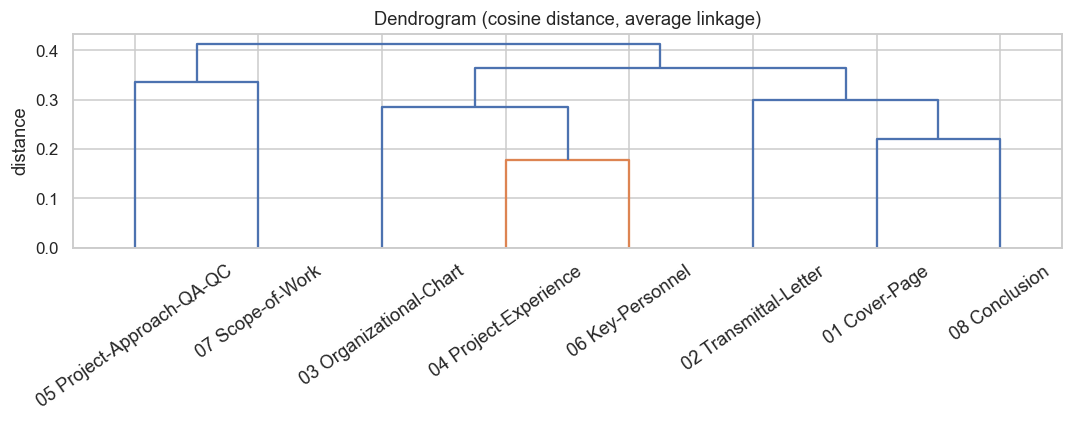

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

cos_dist = 1 - cos_sim
np.fill_diagonal(cos_dist, 0.0)
cos_dist = (cos_dist + cos_dist.T) / 2
condensed = squareform(cos_dist, checks=False)
Z = linkage(condensed, method="average")

g = sns.clustermap(
    pd.DataFrame(cos_sim, index=labels, columns=labels),
    row_linkage=Z,
    col_linkage=Z,
    cmap="viridis",
    figsize=(9, 9),
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "cosine similarity"},
)
g.fig.suptitle("Hierarchically-clustered cosine similarity", y=1.02)
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, labels=labels, leaf_rotation=35, ax=ax, color_threshold=0.5 * max(Z[:, 2]))
ax.set_title("Dendrogram (cosine distance, average linkage)")
ax.set_ylabel("distance")
plt.tight_layout()
plt.show()

## 6. Per-document embedding signature

Heatmap of each document's raw embedding vector. We show the highest-variance
dimensions so the differences between documents are visible.

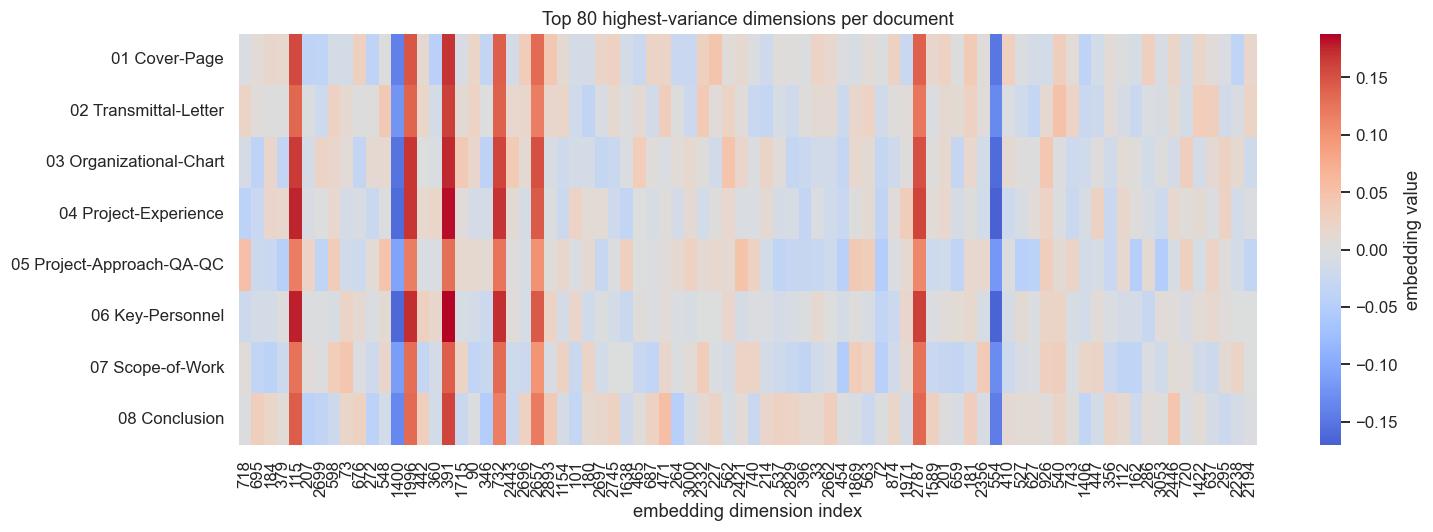

In [9]:
top_k = 80
dim_variance = X.var(axis=0)
top_dims = np.argsort(dim_variance)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    X[:, top_dims],
    yticklabels=labels,
    xticklabels=top_dims,
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "embedding value"},
    ax=ax,
)
ax.set_title(f"Top {top_k} highest-variance dimensions per document")
ax.set_xlabel("embedding dimension index")
plt.tight_layout()
plt.show()